In [ ]:
# Import the Cleaned Dataset

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/telco_cleaned.csv')
print(df.shape)
df.head()

(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# ============================================================
# tenure cohorts 
# ============================================================

bins = [0, 6, 12, 24, 36, 48, 60, 72]
labels = ['0-6 months', '7-12 months', '13-24 months', '25-36 months', '37-48 months', '49-60 months', '61-72 months']

df['tenure_cohort'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

cohort_churn = (
    df.groupby('tenure_cohort',observed = True)['Churn']
    .value_counts(normalize=True)
    .unstack() * 100
).round(2)

print(cohort_churn)

Churn             No    Yes
tenure_cohort              
0-6 months     47.06  52.94
7-12 months    64.11  35.89
13-24 months   71.29  28.71
25-36 months   78.37  21.63
37-48 months   80.97  19.03
49-60 months   85.58  14.42
61-72 months   93.39   6.61


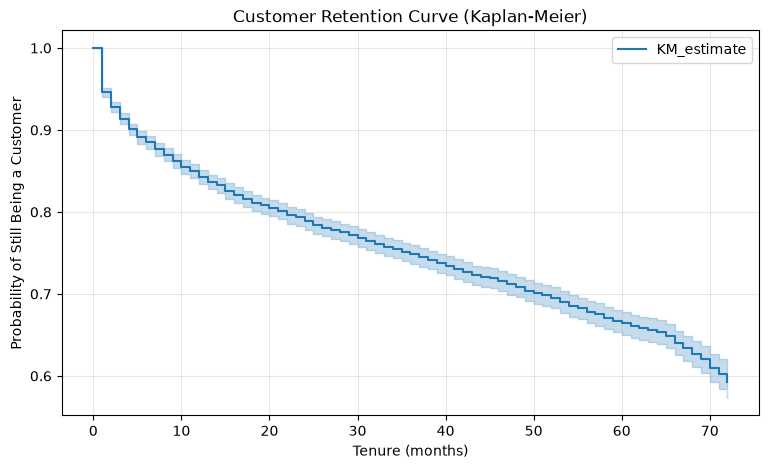

6     0.884826
12    0.843200
24    0.788736
36    0.748545
48    0.708840
60    0.664404
72    0.592790
Name: KM_estimate, dtype: float64


In [ ]:
# "Kaplan–Meier Curve: Customer Survival vs. Churn"

from lifelines import KaplanMeierFitter

# lifelines needs churn as a 1/0 flag 
df['churn_flag'] = (df['Churn'] == 'Yes').astype(int)

kmf = KaplanMeierFitter()

# Two required inputs:
# duration = how long we've observed this customer (their tenure)
# event_observed = did the "event" (churn) happen? 1 = yes, 0 = still active 
kmf.fit(durations=df['tenure'], event_observed=df['churn_flag'])

plt.figure(figsize=(9,5))
kmf.plot_survival_function()
plt.title('Customer Retention Curve (Kaplan-Meier)')
plt.xlabel('Tenure (months)')
plt.ylabel('Probability of Still Being a Customer')
plt.grid(alpha=0.3)

plt.savefig('../reports/figures/retention_curve_overall.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the actual survival probability at key milestones
print(kmf.survival_function_at_times([6, 12, 24, 36, 48, 60, 72]))

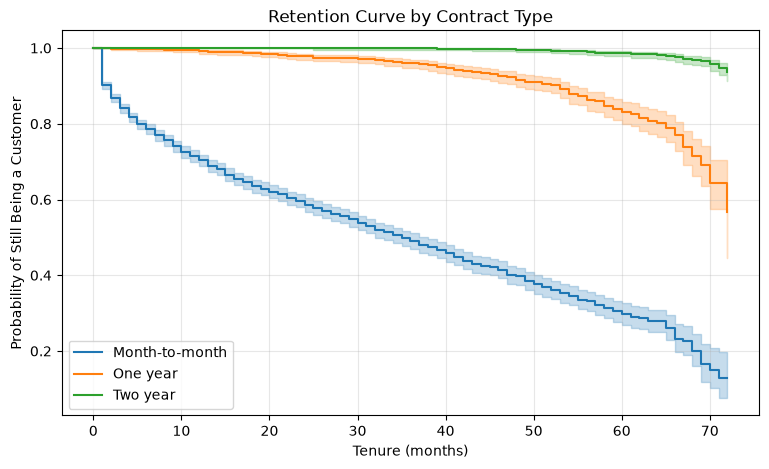

In [ ]:
# Retention Curve by Contract Type

plt.figure(figsize=(9,5))

for contract_type in df['Contract'].unique():
    mask = df['Contract'] == contract_type
    kmf.fit(durations=df.loc[mask, 'tenure'], 
            event_observed=df.loc[mask, 'churn_flag'], 
            label=contract_type)
    kmf.plot_survival_function()

plt.title('Retention Curve by Contract Type')
plt.xlabel('Tenure (months)')
plt.ylabel('Probability of Still Being a Customer')
plt.grid(alpha=0.3)

plt.savefig('../reports/figures/retention_curve_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()